**Assingment - 17 (Advance SQL)**

1 . What is a Common Table Expression (CTE), and how does it improve SQL query readability.

Answer - A Common Table Expression (CTE) is a temporary, named result set that you can reference within a single SELECT, INSERT, UPDATE, or DELETE statement. It is defined using the WITH clause and exists only during the execution of that specific query.

How it Improves Readability

* Modularization: It allows you to break down complex queries into smaller, logical building blocks rather than using deeply nested subqueries.

* Sequential Logic: You can define multiple CTEs in a single query, making it easier for someone to read the logic step-by-step from top to bottom.

* Code Reusability: A CTE can be referenced multiple times within the same main query, which eliminates the need to repeat the same subquery code.

* Self-Documenting Code: Because you give the CTE a descriptive name (e.g., WITH MonthlySales AS ...), it serves as documentation for what that specific part of the query is doing.

2. Why are some views updatable while others are read-only? Explain with an example.

Answer -A view is updatable if the database engine can map the changes back to exactly one row in a single underlying base table. It becomes read-only if the view is "complex" and the mapping is ambiguous.

* Updatable View: A simple view that selects specific columns from one table without any calculations.

* Read-Only View: Views that use DISTINCT, GROUP BY, HAVING, UNION, or certain Joins are usually read-only because the database doesn't know which specific source record to change.

Example:

If you have a view Sales_Summary that uses SUM(Price) grouped by Date, you cannot "update" the sum because the database wouldn't know which individual sale's price to adjust to reach that new total.

3. What advantages do stored procedures offer compared to writing raw SQL queries repeatedly?

Answer -
* Performance: They are compiled once and stored in the database, reducing parsing time.

* Security: Users can be given permission to execute a procedure without having direct access to the underlying tables.

* Reduced Network Traffic: Instead of sending a massive block of SQL code over the network, you only send the procedure name and parameters.

* Maintenance: If business logic changes, you update it in one place (the procedure) rather than in every application that calls it.


4. What is the purpose of triggers in a database? Mention one use case where a trigger is essential.

Answer - The purpose of a trigger is to automatically execute a piece of code in response to a specific event, such as an INSERT, UPDATE, or DELETE on a table.

Essential Use Case: Audit Logging

When a user updates their "Account Balance," a trigger can automatically insert a record into a separate Audit_Log table containing the old balance, the new balance, and the timestamp. This ensures a permanent, unalterable trail of changes for security and compliance.

5.  Explain the need for data modelling and normalization when designing a database.

Answer - Data modeling is the "blueprint" phase, while normalization is the process of organizing that data to reduce redundancy.

* Eliminating Redundancy: Normalization ensures that each piece of data is stored in only one place, which saves storage space.

* Data Integrity: It prevents "Update Anomalies." For example, if a customer's address is stored in ten different places and they move, you might forget to update one, leading to inconsistent data.

* Efficiency: A well-modeled database is easier to query and scales better as the volume of data grows.

6.  Write a CTE to calculate the total revenue for each product.

Answer -

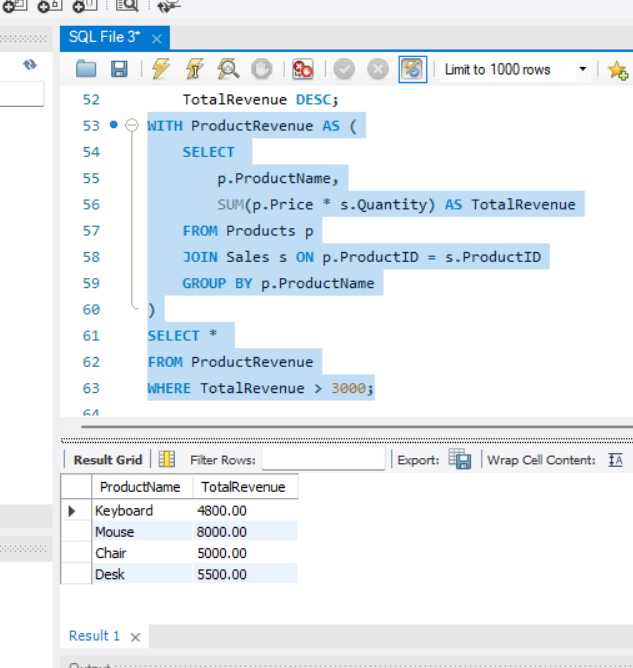

7. Create a view named  vw_CategorySummary that shows:
Category, TotalProducts, AveragePrice.

Answer -

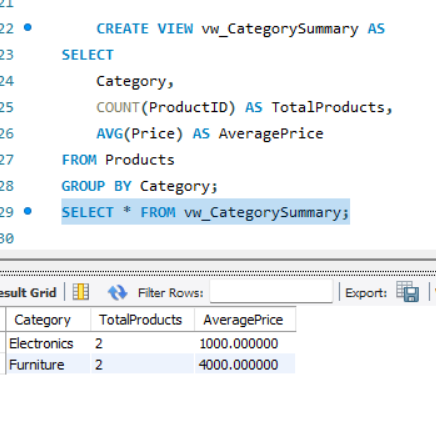

8. Create an updatable view containing ProductID, ProductName, and Price.
Then update the price of ProductID = 1 using the view.

Answer -

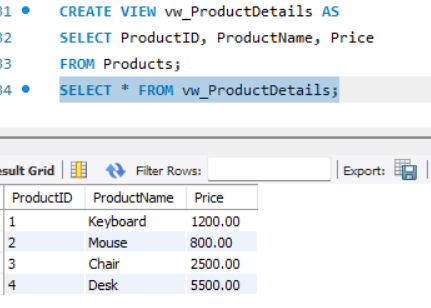

9. Create a stored procedure that accepts a category name and returns all products belonging to that category.

Answer - SQL Query

CREATE PROCEDURE GetProductsByCategory(IN catName VARCHAR(50))
BEGIN
    SELECT *
    FROM Products
    WHERE Category = catName;
END //

DELIMITER ;

CALL GetProductsByCategory('Electronics');


10. Create an AFTER DELETE trigger on the table ProductArchive timestamp.
Productstable that archives deleted product rows into a new . The archive should store ProductID, ProductName, Category, Price, and DeletedAt timestamp.

Answer -

To create an AFTER DELETE trigger for the Products table that archives deleted data, you can use the following SQL syntax. This script assumes the ProductArchive table already exists with the specified columns.

SQL Implementation (MySQL/MariaDB)

In MySQL, the OLD keyword is used to access the values of the row that was just deleted.



DELIMITER //

CREATE TRIGGER trg_AfterProductDelete
AFTER DELETE ON Products
FOR EACH ROW
BEGIN
    INSERT INTO ProductArchive (ProductID, ProductName, Category, Price, DeletedAt)
    VALUES (OLD.ProductID, OLD.ProductName, OLD.Category, OLD.Price, NOW());
END //

DELIMITER ;


SQL Implementation (SQL Server / T-SQL)

In SQL Server, deleted rows are stored in a temporary memory-resident table called DELETED.



CREATE TRIGGER trg_AfterProductDelete
ON Products
AFTER DELETE
AS
BEGIN
    INSERT INTO ProductArchive (ProductID, ProductName, Category, Price, DeletedAt)
    SELECT ProductID, ProductName, Category, Price, GETDATE()
    FROM DELETED;
END;


Key Elements:


AFTER DELETE: Specifies that the trigger should run only after the deletion is successful.

OLD / DELETED: These are special references used to retrieve the data from the row(s) being removed.

NOW() / GETDATE(): Functions used to capture the current timestamp for the DeletedAt column.